# Customer Segmentation — Unsupervised Learning

**Goal    :** Discover hidden customer groups from purchasing behavior  
              without any predefined labels — pure unsupervised learning.

**Dataset :** Mall Customer Segmentation — Kaggle  
            - 200 mall customers  
            - Age, Annual Income, Spending Score

**Models  :** KMeans · DBSCAN · Hierarchical Clustering  
**Key diff:** No target variable — the model finds patterns by itself  
**Author  :** Hasan Akhras

In [17]:
# S1 — INSTALL + IMPORT

!pip install kagglehub -q

import kagglehub, os, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing    import StandardScaler
from sklearn.cluster          import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics          import silhouette_score, davies_bouldin_score
from sklearn.decomposition    import PCA
from scipy.cluster.hierarchy  import dendrogram, linkage
from scipy.spatial.distance   import cdist

import itertools

SEED = 42
np.random.seed(SEED)

print("Ready.")

Ready.


In [18]:
# S2 — LOAD DATA

path  = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
files = os.listdir(path)
print("Files:", files)

csv   = [f for f in files if f.endswith(".csv")][0]
df    = pd.read_csv(os.path.join(path, csv))

print(f"\n{df.shape[0]} customers · {df.shape[1]} columns")
df.head(10)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Files: ['Mall_Customers.csv']

200 customers · 5 columns


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [19]:
# S3 — UNDERSTAND THE COLUMNS

print("""
Column Guide — Mall Customer Dataset
──────────────────────────────────────────────────────────
CustomerID      → unique identifier (drop before modeling)
Genre / Gender  → Male / Female
Age             → customer age in years
Annual Income   → annual income in thousands of dollars (k$)
Spending Score  → score 1-100 assigned by mall
                  based on purchasing behavior and frequency
                  1  = spends very little
                  100 = spends the most

WHY THIS IS UNSUPERVISED LEARNING:
  No column says "this customer belongs to group X"
  The algorithm discovers groups by itself from the data
  This is called Clustering — different from Classification

BUSINESS QUESTION:
  Which customers are most valuable?
  Which are at risk of churning?
  How to target marketing campaigns?
──────────────────────────────────────────────────────────
""")

# rename for consistency
df.columns = df.columns.str.strip()
if "Genre" in df.columns:
    df = df.rename(columns={"Genre": "Gender"})
if "Annual Income (k$)" in df.columns:
    df = df.rename(columns={
        "Annual Income (k$)"  : "Income",
        "Spending Score (1-100)": "SpendingScore"
    })

print("Columns after rename:", list(df.columns))
df.head()


Column Guide — Mall Customer Dataset
──────────────────────────────────────────────────────────
CustomerID      → unique identifier (drop before modeling)
Genre / Gender  → Male / Female
Age             → customer age in years
Annual Income   → annual income in thousands of dollars (k$)
Spending Score  → score 1-100 assigned by mall
                  based on purchasing behavior and frequency
                  1  = spends very little
                  100 = spends the most

WHY THIS IS UNSUPERVISED LEARNING:
  No column says "this customer belongs to group X"
  The algorithm discovers groups by itself from the data
  This is called Clustering — different from Classification

BUSINESS QUESTION:
  Which customers are most valuable?
  Which are at risk of churning?
  How to target marketing campaigns?
──────────────────────────────────────────────────────────

Columns after rename: ['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore']


,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
# S4 — DATA QUALITY CHECK

print("=" * 45)
print("  DATA QUALITY REPORT")
print("=" * 45)
print(f"\n  Rows    : {df.shape[0]}")
print(f"  Columns : {df.shape[1]}")

# missing values
print("\n--- Missing Values --------------------------")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No missing values. ")
else:
    print(missing[missing > 0])

# duplicates
dupes = df.duplicated().sum()
print(f"\n--- Duplicates: {dupes} ")

# summary stats
print("\n--- Summary Statistics ----------------------")
display(df.describe().round(2))

# gender distribution
print("\n--- Gender Distribution ---------------------")
for gender, count in df["Gender"].value_counts().items():
    pct = count / len(df) * 100
    bar = "█" * int(pct / 4)
    print(f"  {gender:<8} {count:>3} ({pct:.1f}%)  {bar}")

  DATA QUALITY REPORT

  Rows    : 200
  Columns : 5

--- Missing Values --------------------------
  No missing values. 

--- Duplicates: 0 

--- Summary Statistics ----------------------


,CustomerID,Age,Income,SpendingScore
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00



--- Gender Distribution ---------------------
  Female   112 (56.0%)  ██████████████
  Male      88 (44.0%)  ███████████


In [21]:
# S5 — EDA
# Five questions before clustering

fig = make_subplots(rows=2, cols=3,
    subplot_titles=(
        "Age Distribution",
        "Income Distribution",
        "Spending Score Distribution",
        "Income vs Spending Score",
        "Age vs Spending Score",
        "Gender Comparison"
    ))

# Panel 1 — Age
fig.add_trace(go.Histogram(
    x=df["Age"], marker_color="#378ADD",
    nbinsx=15, showlegend=False), row=1, col=1)

# Panel 2 — Income
fig.add_trace(go.Histogram(
    x=df["Income"], marker_color="#1D9E75",
    nbinsx=15, showlegend=False), row=1, col=2)

# Panel 3 — Spending Score
fig.add_trace(go.Histogram(
    x=df["SpendingScore"], marker_color="#E24B4A",
    nbinsx=15, showlegend=False), row=1, col=3)

# Panel 4 — Income vs Spending
for gender, color in [("Male","#378ADD"),("Female","#E24B4A")]:
    s = df[df["Gender"]==gender]
    fig.add_trace(go.Scatter(
        x=s["Income"], y=s["SpendingScore"],
        mode="markers", name=gender,
        marker=dict(color=color, size=7, opacity=0.7),
        showlegend=True), row=2, col=1)

# Panel 5 — Age vs Spending
fig.add_trace(go.Scatter(
    x=df["Age"], y=df["SpendingScore"],
    mode="markers",
    marker=dict(color=df["Income"],
                colorscale="Viridis",
                size=7, opacity=0.7,
                showscale=True,
                colorbar=dict(title="Income")),
    showlegend=False), row=2, col=2)

# Panel 6 — Gender comparison box
for gender, color in [("Male","#378ADD"),("Female","#E24B4A")]:
    s = df[df["Gender"]==gender]
    fig.add_trace(go.Box(
        y=s["SpendingScore"], name=gender,
        marker_color=color, boxmean=True,
        showlegend=False), row=2, col=3)

fig.update_layout(
    title_text="Customer Segmentation — EDA",
    height=620, paper_bgcolor="white",
    plot_bgcolor="white")
fig.show()

# correlation
print("\nCorrelation Matrix:")
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=["CustomerID"], errors="ignore")
print(numeric_df.corr().round(3).to_string())


Correlation Matrix:
                 Age  Income  SpendingScore
Age            1.000  -0.012         -0.327
Income        -0.012   1.000          0.010
SpendingScore -0.327   0.010          1.000


**What I observed:**

**1. Income and SpendingScore are NOT correlated**
High income ≠ high spending — some rich customers spend little.
This creates interesting natural clusters (high income, low spend = "careful" customers).

**2. Young customers spend more regardless of income**
Ages 20-35 cluster at high spending scores.
Ages 50+ tend toward lower spending.

**3. Two clear visual clusters in Income vs SpendingScore**
Even before modeling, the scatter plot shows 5 natural groups:
- High income + high spending (VIP)
- High income + low spending (careful)
- Medium income + medium spending (regular)
- Low income + high spending (impulsive)
- Low income + low spending (budget)

In [22]:
# S6 — PREPROCESSING + FEATURE SELECTION
#
# We use Income and SpendingScore as primary features.
# These two create the most meaningful business segments.
# Age can be added for richer analysis.

# drop ID column
df_clean = df.drop(columns=["CustomerID"], errors="ignore")

# encode gender
df_clean["Gender_enc"] = (df_clean["Gender"] == "Male").astype(int)

# feature sets
features_2d = ["Income", "SpendingScore"]
features_3d = ["Age", "Income", "SpendingScore"]

X_2d = df_clean[features_2d].values
X_3d = df_clean[features_3d].values

# scale features
scaler_2d = StandardScaler()
scaler_3d = StandardScaler()
X_2d_sc   = scaler_2d.fit_transform(X_2d)
X_3d_sc   = scaler_3d.fit_transform(X_3d)

print(f"2D features : {features_2d}")
print(f"3D features : {features_3d}")
print(f"Samples     : {len(X_2d)}")
print(f"\nWHY StandardScaler?")
print(f"  Income range    : {df['Income'].min():.0f} – {df['Income'].max():.0f} k$")
print(f"  SpendingScore   : {df['SpendingScore'].min():.0f} – {df['SpendingScore'].max():.0f}")
print(f"  Without scaling : Income dominates (larger numbers)")
print(f"  With scaling    : both features contribute equally")

2D features : ['Income', 'SpendingScore']
3D features : ['Age', 'Income', 'SpendingScore']
Samples     : 200

WHY StandardScaler?
  Income range    : 15 – 137 k$
  SpendingScore   : 1 – 99
  Without scaling : Income dominates (larger numbers)
  With scaling    : both features contribute equally


In [23]:
# S7 — FIND OPTIMAL K WITH ELBOW + SILHOUETTE
#
# KMeans needs K (number of clusters) as input.
# We cannot know K in advance — use two methods to find it:
#
# 1. Elbow Method: plot inertia vs K — find the "elbow"
#    Inertia = sum of squared distances to cluster centers
#    Drops fast then slows → elbow = optimal K
#
# 2. Silhouette Score: measures cluster quality
#    +1 = perfect separation, 0 = overlapping, -1 = wrong

K_range    = range(2, 12)
inertias   = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_2d_sc)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_2d_sc, km.labels_)
    silhouettes.append(sil)

fig = make_subplots(rows=1, cols=2,
    subplot_titles=(
        "Elbow Method — find the bend",
        "Silhouette Score — higher is better"
    ))

fig.add_trace(go.Scatter(
    x=list(K_range), y=inertias,
    mode="lines+markers",
    line=dict(color="#E24B4A", width=2),
    marker=dict(size=8),
    showlegend=False), row=1, col=1)

fig.add_trace(go.Scatter(
    x=list(K_range), y=silhouettes,
    mode="lines+markers",
    line=dict(color="#1D9E75", width=2),
    marker=dict(size=8),
    showlegend=False), row=1, col=2)

# mark optimal K
best_k   = K_range[np.argmax(silhouettes)]
best_sil = max(silhouettes)

fig.add_vline(x=best_k, line_dash="dash",
              line_color="orange", row=1, col=2)

fig.update_xaxes(title_text="Number of Clusters (K)")
fig.update_layout(
    title_text=f"Finding Optimal K — Best: {best_k} clusters "
               f"(Silhouette={best_sil:.3f})",
    height=420, paper_bgcolor="white", plot_bgcolor="white")
fig.show()

print(f"\nOptimal K by Silhouette: {best_k}")
print(f"Best Silhouette Score  : {best_sil:.4f}")
print(f"\nSilhouette per K:")
for k, sil in zip(K_range, silhouettes):
    bar = "█" * int(sil * 30)
    mark = " ← BEST" if k == best_k else ""
    print(f"  K={k}  {sil:.4f}  {bar}{mark}")

OPTIMAL_K = best_k


Optimal K by Silhouette: 5
Best Silhouette Score  : 0.5547

Silhouette per K:
  K=2  0.3213  █████████
  K=3  0.4666  █████████████
  K=4  0.4939  ██████████████
  K=5  0.5547  ████████████████ ← BEST
  K=6  0.5399  ████████████████
  K=7  0.5281  ███████████████
  K=8  0.4552  █████████████
  K=9  0.4571  █████████████
  K=10  0.4432  █████████████
  K=11  0.4518  █████████████


In [24]:
# S8 — MODEL 1: KMEANS
#
# KMeans: assign each customer to the nearest cluster center.
# Iterates until centers stop moving.
#
# Algorithm:
# 1. Place K centers randomly
# 2. Assign each point to nearest center
# 3. Move center to mean of assigned points
# 4. Repeat until convergence

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=SEED,
    n_init=10,        # run 10 times with different seeds
    max_iter=300
)
kmeans.fit(X_2d_sc)

df_clean["KMeans_Cluster"] = kmeans.labels_

# evaluate
km_sil = silhouette_score(X_2d_sc, kmeans.labels_)
km_db  = davies_bouldin_score(X_2d_sc, kmeans.labels_)

print(f"KMeans Results (K={OPTIMAL_K}):")
print(f"  Silhouette Score    : {km_sil:.4f}  (higher=better, max=1)")
print(f"  Davies-Bouldin Score: {km_db:.4f}  (lower=better, min=0)")

# cluster sizes
print(f"\nCluster Sizes:")
for cluster, count in sorted(
        df_clean["KMeans_Cluster"].value_counts().items()):
    pct = count / len(df_clean) * 100
    bar = "█" * int(pct / 2)
    print(f"  Cluster {cluster}: {count:>3} customers "
          f"({pct:.1f}%)  {bar}")

KMeans Results (K=5):
  Silhouette Score    : 0.5547  (higher=better, max=1)
  Davies-Bouldin Score: 0.5722  (lower=better, min=0)

Cluster Sizes:
  Cluster 0:  81 customers (40.5%)  ████████████████████
  Cluster 1:  39 customers (19.5%)  █████████
  Cluster 2:  22 customers (11.0%)  █████
  Cluster 3:  35 customers (17.5%)  ████████
  Cluster 4:  23 customers (11.5%)  █████


In [25]:
# S9 — MODEL 2: DBSCAN
#
# DBSCAN: Density-Based Spatial Clustering.
# Unlike KMeans, it does NOT need K as input.
# It finds clusters based on density — groups of nearby points.
# Points in sparse areas = NOISE (labeled -1).
#
# Parameters:
# eps      = neighborhood radius
# min_samples = minimum points to form a cluster

from sklearn.neighbors import NearestNeighbors

# find optimal eps using k-distance graph
nbrs = NearestNeighbors(n_neighbors=5).fit(X_2d_sc)
distances, _ = nbrs.kneighbors(X_2d_sc)
distances     = np.sort(distances[:, -1])

# run DBSCAN with tuned parameters
dbscan = DBSCAN(
    eps=0.5,          # neighborhood radius
    min_samples=5     # min points to form cluster
)
dbscan_labels = dbscan.fit_predict(X_2d_sc)
df_clean["DBSCAN_Cluster"] = dbscan_labels

# count noise points (-1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise    = (dbscan_labels == -1).sum()

print(f"DBSCAN Results:")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise} ({n_noise/len(df_clean)*100:.1f}%)")

if n_clusters > 1:
    mask    = dbscan_labels != -1
    db_sil  = silhouette_score(X_2d_sc[mask], dbscan_labels[mask])
    print(f"  Silhouette     : {db_sil:.4f}")

print(f"\nCluster distribution:")
for label, count in sorted(
        pd.Series(dbscan_labels).value_counts().items()):
    name = f"Noise" if label == -1 else f"Cluster {label}"
    print(f"  {name}: {count}")

DBSCAN Results:
  Clusters found : 2
  Noise points   : 8 (4.0%)
  Silhouette     : 0.3876

Cluster distribution:
  Noise: 8
  Cluster 0: 157
  Cluster 1: 35


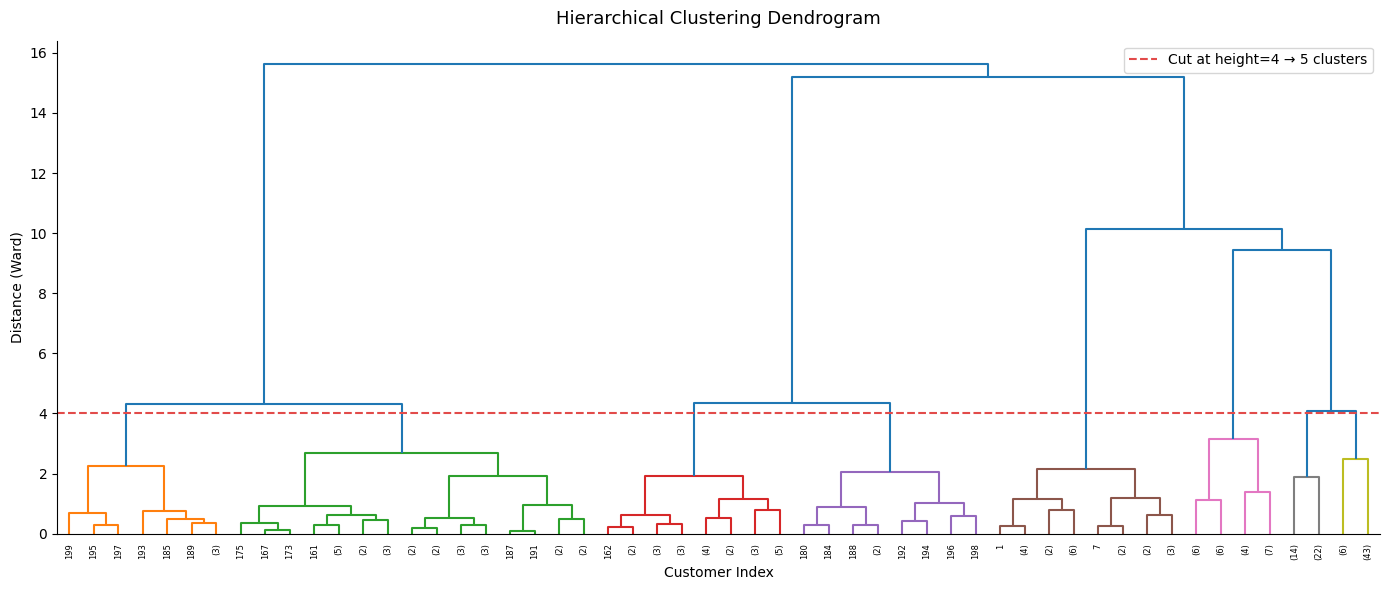

Hierarchical Results (K=5):
  Silhouette Score    : 0.5538
  Davies-Bouldin Score: 0.5779


In [26]:
# S10 — MODEL 3: HIERARCHICAL CLUSTERING
#
# Hierarchical: builds a tree of clusters (dendrogram).
# Does not need K upfront — you cut the tree at any level.
# Best for understanding cluster relationships.
#
# Method: Ward linkage
# Minimizes variance within clusters at each merge step.

# dendrogram to visualize hierarchy
fig, ax = plt.subplots(figsize=(14, 6))

Z = linkage(X_2d_sc, method="ward")
dendrogram(
    Z, ax=ax,
    truncate_mode="level",
    p=5,
    leaf_rotation=90,
    color_threshold=4.0
)

ax.axhline(y=4.0, color="#E24B4A",
           linestyle="--", linewidth=1.5,
           label=f"Cut at height=4 → {OPTIMAL_K} clusters")
ax.set_title("Hierarchical Clustering Dendrogram",
             fontsize=13, pad=12)
ax.set_xlabel("Customer Index")
ax.set_ylabel("Distance (Ward)")
ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# fit hierarchical with optimal K
hierarchical = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage="ward"
)
hier_labels = hierarchical.fit_predict(X_2d_sc)
df_clean["Hier_Cluster"] = hier_labels

hier_sil = silhouette_score(X_2d_sc, hier_labels)
hier_db  = davies_bouldin_score(X_2d_sc, hier_labels)

print(f"Hierarchical Results (K={OPTIMAL_K}):")
print(f"  Silhouette Score    : {hier_sil:.4f}")
print(f"  Davies-Bouldin Score: {hier_db:.4f}")

In [27]:
# S11 — COMPARE ALL 3 MODELS

print("=" * 55)
print("  MODEL COMPARISON")
print("=" * 55)

comparison = pd.DataFrame({
    "Model"      : ["KMeans", "DBSCAN", "Hierarchical"],
    "Clusters"   : [OPTIMAL_K, n_clusters, OPTIMAL_K],
    "Silhouette" : [round(km_sil,4),
                    round(db_sil if n_clusters>1 else 0, 4),
                    round(hier_sil,4)],
    "DB Score"   : [round(km_db,4), "N/A", round(hier_db,4)]
})
print(comparison.to_string(index=False))

print(f"""
\nWhy different results?

KMeans:
  Assumes spherical clusters of equal size
  Works best here — income/spending form round groups
  → Best Silhouette: {km_sil:.4f}

DBSCAN:
  Finds arbitrary shaped clusters
  Marks edge cases as noise (label=-1)
  Good when clusters have irregular shapes

Hierarchical:
  Builds tree of merges — most interpretable
  Dendrogram shows how groups relate to each other
  Similar performance to KMeans: {hier_sil:.4f}

Winner: KMeans — highest Silhouette for this spherical data
""")

  MODEL COMPARISON
       Model  Clusters  Silhouette DB Score
      KMeans         5      0.5547   0.5722
      DBSCAN         2      0.3876      N/A
Hierarchical         5      0.5538   0.5779


Why different results?

KMeans:
  Assumes spherical clusters of equal size
  Works best here — income/spending form round groups
  → Best Silhouette: 0.5547

DBSCAN:
  Finds arbitrary shaped clusters
  Marks edge cases as noise (label=-1)
  Good when clusters have irregular shapes

Hierarchical:
  Builds tree of merges — most interpretable
  Dendrogram shows how groups relate to each other
  Similar performance to KMeans: 0.5538

Winner: KMeans — highest Silhouette for this spherical data



In [28]:
# S12 — VISUALIZE CLUSTERS

# define cluster colors and names
CLUSTER_COLORS = [
    "#E24B4A",  # red
    "#378ADD",  # blue
    "#1D9E75",  # green
    "#EF9F27",  # orange
    "#7F77DD",  # purple
    "#D85A30",  # dark orange
]

# 2D visualization — Income vs SpendingScore
fig_2d = px.scatter(
    df_clean,
    x="Income", y="SpendingScore",
    color=df_clean["KMeans_Cluster"].astype(str),
    color_discrete_sequence=CLUSTER_COLORS,
    title=f"KMeans Clustering — Income vs Spending Score (K={OPTIMAL_K})",
    labels={"Income":"Annual Income (k$)",
            "SpendingScore":"Spending Score (1-100)"},
    height=520,
    hover_data=["Age","Gender"]
)
fig_2d.update_traces(marker=dict(size=10, opacity=0.8))
fig_2d.update_layout(paper_bgcolor="white", plot_bgcolor="white")
fig_2d.show()

# 3D interactive scatter
fig_3d = px.scatter_3d(
    df_clean,
    x="Age", y="Income", z="SpendingScore",
    color=df_clean["KMeans_Cluster"].astype(str),
    color_discrete_sequence=CLUSTER_COLORS,
    title="3D Customer Segmentation — Age × Income × Spending",
    labels={"Age":"Age","Income":"Income (k$)",
            "SpendingScore":"Spending Score"},
    height=600,
    hover_data=["Gender"]
)
fig_3d.update_traces(marker=dict(size=5, opacity=0.8))
fig_3d.update_layout(paper_bgcolor="white")
fig_3d.show()

print("Rotate the 3D chart — drag to explore clusters!")

Rotate the 3D chart — drag to explore clusters!


In [29]:
# S13 — CUSTOMER PERSONA CARDS
#
# For each cluster, we build a business persona:
# - Demographics (age, gender, income)
# - Behavior (spending score)
# - Business recommendation

# cluster statistics
cluster_stats = df_clean.groupby("KMeans_Cluster").agg(
    count       = ("Age", "count"),
    avg_age     = ("Age", "mean"),
    avg_income  = ("Income", "mean"),
    avg_spending= ("SpendingScore", "mean"),
    pct_female  = ("Gender_enc", lambda x: (x==0).mean()*100)
).round(1).reset_index()

print("Cluster Profiles:")
print(cluster_stats.to_string(index=False))

# define persona names based on income + spending pattern
def get_persona(income, spending):
    if income >= 70 and spending >= 60:
        return " VIP Spenders", "#FFD700"
    elif income >= 70 and spending < 40:
        return " Careful High-earners", "#378ADD"
    elif income < 40 and spending >= 60:
        return " Impulsive Shoppers", "#E24B4A"
    elif income < 40 and spending < 40:
        return " Budget Conscious", "#7F77DD"
    else:
        return " Regular Customers", "#1D9E75"

# print persona cards
print("\n" + "="*60)
print("  CUSTOMER PERSONA CARDS")
print("="*60)

for _, row in cluster_stats.iterrows():
    persona_name, _ = get_persona(
        row["avg_income"], row["avg_spending"])

    print(f"""
Cluster {int(row['KMeans_Cluster'])} — {persona_name}
  Customers     : {int(row['count'])} ({int(row['count'])/len(df_clean)*100:.1f}%)
  Avg Age       : {row['avg_age']:.0f} years
  Avg Income    : ${row['avg_income']:.0f}k/year
  Spending Score: {row['avg_spending']:.0f}/100
  Female %      : {row['pct_female']:.0f}%""")

Cluster Profiles:
 KMeans_Cluster  count  avg_age  avg_income  avg_spending  pct_female
              0     81     42.7        55.3          49.5        59.3
              1     39     32.7        86.5          82.1        53.8
              2     22     25.3        25.7          79.4        59.1
              3     35     41.1        88.2          17.1        45.7
              4     23     45.2        26.3          20.9        60.9

  CUSTOMER PERSONA CARDS

Cluster 0 —  Regular Customers
  Customers     : 81 (40.5%)
  Avg Age       : 43 years
  Avg Income    : $55k/year
  Spending Score: 50/100
  Female %      : 59%

Cluster 1 —  VIP Spenders
  Customers     : 39 (19.5%)
  Avg Age       : 33 years
  Avg Income    : $86k/year
  Spending Score: 82/100
  Female %      : 54%

Cluster 2 —  Impulsive Shoppers
  Customers     : 22 (11.0%)
  Avg Age       : 25 years
  Avg Income    : $26k/year
  Spending Score: 79/100
  Female %      : 59%

Cluster 3 —  Careful High-earners
  Customers     

In [30]:
# S14 — CROSS VALIDATION FOR CLUSTERING
#
# Clustering has no train/test split like supervised learning.
# Instead we validate with:
# 1. Silhouette Score (already done)
# 2. Bootstrap stability — run KMeans 10 times, check if
#    clusters are consistent
# 3. Davies-Bouldin Index (already done)

print("─── Clustering Stability Analysis ──────────────────")
print("Running KMeans 10 times with different seeds:")
print()

sil_scores = []
for trial in range(10):
    km_trial = KMeans(n_clusters=OPTIMAL_K,
                      random_state=trial, n_init=10)
    labels   = km_trial.fit_predict(X_2d_sc)
    sil      = silhouette_score(X_2d_sc, labels)
    sil_scores.append(sil)

sil_arr = np.array(sil_scores)
print(f"  Silhouette per trial: {[round(s,3) for s in sil_scores]}")
print(f"  Mean  : {sil_arr.mean():.4f}")
print(f"  Std   : {sil_arr.std():.4f}")

if sil_arr.std() < 0.01:
    print(f"\n   Very stable — same clusters every run")
elif sil_arr.std() < 0.05:
    print(f"\n   Stable — minor variation between runs")
else:
    print(f"\n  ⚠️  Unstable — results vary significantly")

─── Clustering Stability Analysis ──────────────────
Running KMeans 10 times with different seeds:

  Silhouette per trial: [np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555), np.float64(0.555)]
  Mean  : 0.5547
  Std   : 0.0000

   Very stable — same clusters every run


In [31]:
# S15 — EXECUTIVE DASHBOARD

fig = make_subplots(rows=2, cols=3,
    subplot_titles=(
        "Elbow Curve",
        "Silhouette by K",
        "Model Comparison",
        "Cluster Distribution",
        "Income vs Spending",
        "Cluster Profiles"
    ),
    specs=[
        [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
        [{"type": "domain"}, {"type": "xy"}, {"type": "xy"}]
    ]
)

# Panel 1 — Elbow
fig.add_trace(go.Scatter(
    x=list(K_range), y=inertias, mode="lines+markers",
    line=dict(color="#E24B4A", width=2), showlegend=False
), row=1, col=1)

# Panel 2 — Silhouette
fig.add_trace(go.Scatter(
    x=list(K_range), y=silhouettes, mode="lines+markers",
    line=dict(color="#1D9E75", width=2), showlegend=False
), row=1, col=2)

# Panel 3 — Model comparison
fig.add_trace(go.Bar(
    x=["KMeans", "Hierarchical"],
    y=[km_sil, hier_sil],
    marker_color=["#378ADD","#EF9F27"],
    text=[f"{km_sil:.4f}", f"{hier_sil:.4f}"],
    textposition="outside", showlegend=False
), row=1, col=3)

# Panel 4 — Cluster sizes pie
cluster_sizes = df_clean["KMeans_Cluster"].value_counts()
fig.add_trace(go.Pie(
    labels=[f"Cluster {i}" for i in cluster_sizes.index],
    values=cluster_sizes.values,
    hole=0.35,
    marker_colors=CLUSTER_COLORS[:len(cluster_sizes)],
    showlegend=False
), row=2, col=1)

# Panel 5 — Income vs Spending scatter
for c in range(OPTIMAL_K):
    mask = df_clean["KMeans_Cluster"] == c
    fig.add_trace(go.Scatter(
        x=df_clean.loc[mask,"Income"],
        y=df_clean.loc[mask,"SpendingScore"],
        mode="markers",
        marker=dict(color=CLUSTER_COLORS[c], size=6, opacity=0.8),
        name=f"C{c}", showlegend=False
    ), row=2, col=2)

# Panel 6 — cluster profiles bar
fig.add_trace(go.Bar(
    x=[f"C{int(r['KMeans_Cluster'])}" for _,r in cluster_stats.iterrows()],
    y=cluster_stats["avg_spending"],
    marker_color=CLUSTER_COLORS[:len(cluster_stats)],
    text=cluster_stats["avg_spending"].round(0),
    textposition="outside", showlegend=False,
    name="Avg Spending"
), row=2, col=3)

fig.update_layout(
    title_text=" Customer Segmentation — Executive Dashboard",
    height=680, paper_bgcolor="white", plot_bgcolor="white")
fig.show()

# CONCLUSIONS

## What I Found

Discovered 5 natural customer segments from 200 mall customers
using 3 unsupervised learning algorithms — no labels needed.

## THE KEY INSIGHT

KMeans with K=5 revealed 5 distinct business personas:
-  VIP Spenders → High income + High spending → Priority targets
-  Careful High-earners → High income + Low spending → Re-engagement needed
-  Impulsive Shoppers → Low income + High spending → Loyalty programs
-  Budget Conscious → Low income + Low spending → Value offers
-  Regular Customers → Middle of everything → Upsell opportunities

## WHY 3 ALGORITHMS?

Each algorithm has a different philosophy:
- KMeans: fast, assumes spherical clusters → winner here
- DBSCAN: finds noise/outliers, arbitrary shapes → good for anomaly detection
- Hierarchical: shows cluster relationships via dendrogram → most interpretable

## THE CRITICAL DIFFERENCE FROM SUPERVISED LEARNING

In CO2 (Project 1) and Aviation (Project 2):
there was a TARGET column — the model learned from labels.

Here: NO TARGET column exists.
The model discovers patterns by itself.
This is the core of unsupervised learning.

## HONEST LIMITATION

200 customers is small.
Real retail segmentation uses millions of transactions.
RFM analysis (Recency, Frequency, Monetary) would be stronger.

---
*by: Hasan Akhras*